<a href="https://colab.research.google.com/github/narayananxyz/deep_learning/blob/main/elective_project_digit_recognition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Load tensorflow
And print the version

In [ ]:
import tensorflow as tf
tf.__version__
from tensorflow import keras
from tensorflow.keras import layers

# Import Dataset

In this case are loading the dataset from a file.

In [ ]:
import h5py
import numpy as np
with h5py.File("/content/drive/MyDrive/mitcourse/elective/SVHN_single_grey1.h5", "r") as f:

    print("=== STRUCTURE ===")
    def print_structure(name, obj):
        if hasattr(obj, 'shape'):
            print(f"  {name}: shape={obj.shape}, dtype={obj.dtype}")
        else:
            print(f"  {name}/  (group)")
    f.visititems(print_structure)

    print("\n=== TOP LEVEL KEYS ===")
    y_train = np.array(f['y_train'])
    print(list(f.keys()))

print(f"Unique classes: {np.unique(y_train)}")
print(f"Class counts:   {np.bincount(y_train)}")
print(f"Num classes:    {len(np.unique(y_train))}")

=== STRUCTURE ===
  X_test: shape=(18000, 32, 32), dtype=float32
  X_train: shape=(42000, 32, 32), dtype=float32
  X_val: shape=(60000, 32, 32), dtype=float32
  y_test: shape=(18000,), dtype=uint8
  y_train: shape=(42000,), dtype=uint8
  y_val: shape=(60000,), dtype=uint8

=== TOP LEVEL KEYS ===
['X_test', 'X_train', 'X_val', 'y_test', 'y_train', 'y_val']
Unique classes: [0 1 2 3 4 5 6 7 8 9]
Class counts:   [4186 4172 4197 4281 4188 4232 4168 4192 4188 4196]
Num classes:    10


In [ ]:
with h5py.File("/content/drive/MyDrive/mitcourse/elective/SVHN_single_grey1.h5", "r") as f:
    X_train = np.array(f['X_train'])
    y_train = np.array(f['y_train'])
    X_val   = np.array(f['X_val'])
    y_val   = np.array(f['y_val'])
    X_test  = np.array(f['X_test'])
    y_test  = np.array(f['y_test'])

print(f"X_train: {X_train.shape}")
print(f"y_train: {y_train.shape}")
print(f"X_val:   {X_val.shape}")
print(f"y_val:   {y_val.shape}")
print(f"X_test:  {X_test.shape}")
print(f"y_test:  {y_test.shape}")

X_train: (42000, 32, 32)
y_train: (42000,)
X_val:   (60000, 32, 32)
y_val:   (60000,)
X_test:  (18000, 32, 32)
y_test:  (18000,)


In [ ]:
# Normalize to 0-1
X_train = X_train / 255.0
X_val   = X_val   / 255.0
X_test  = X_test  / 255.0

print(f"Min: {X_train.min()}")   # should be 0.0
print(f"Max: {X_train.max()}")   # should be 1.0

Min: 0.0
Max: 0.9998999834060669


In [ ]:
model = keras.Sequential([
    keras.Input(shape=(32, 32)),      # ← clean way in Keras 3
    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(10, activation='softmax')
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 690,314 (2.63 MB)

 Trainable params: 690,314 (2.63 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Model compiled successfully!")

Model compiled successfully!


In [ ]:
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=64,
    validation_data=(X_val, y_val),
    verbose=1
)

Epoch 1/20
657/657 ━━━━━━━━━━━━━━━━━━━━ 13s 13ms/step - accuracy: 0.1013 - loss: 2.3114 - val_accuracy: 0.0937 - val_loss: 2.3027
Epoch 2/20
657/657 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.1028 - loss: 2.3028 - val_accuracy: 0.1000 - val_loss: 2.3027
Epoch 3/20
657/657 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.0996 - loss: 2.3029 - val_accuracy: 0.1000 - val_loss: 2.3027
Epoch 4/20
657/657 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.1011 - loss: 2.3028 - val_accuracy: 0.1000 - val_loss: 2.3027
Epoch 5/20
657/657 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.0995 - loss: 2.3028 - val_accuracy: 0.1000 - val_loss: 2.3029
Epoch 6/20
657/657 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.0994 - loss: 2.3028 - val_accuracy: 0.1000 - val_loss: 2.3026
Epoch 7/20
657/657 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.0998 - loss: 2.3027 - val_accuracy: 0.1000 - val_loss: 2.3026
Epoch 8/20
657/657 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.1003 - loss: 2.3027 - val_accuracy: 

In [ ]:
import numpy as np

print("=== DATA CHECK ===")
print(f"X_train min: {X_train.min():.4f}")
print(f"X_train max: {X_train.max():.4f}")
print(f"X_train mean: {X_train.mean():.4f}")
print(f"X_train dtype: {X_train.dtype}")

print("\n=== LABEL CHECK ===")
print(f"y_train unique: {np.unique(y_train)}")
print(f"y_train dtype: {y_train.dtype}")
print(f"y_train sample: {y_train[:10]}")

print("\n=== SAMPLE PREDICTION CHECK ===")
sample = X_train[:1]
pred = model.predict(sample, verbose=0)
print(f"Raw prediction: {pred}")
print(f"Predicted class: {np.argmax(pred)}")
print(f"Actual class: {y_train[0]}")

=== DATA CHECK ===
X_train min: 0.0000
X_train max: 0.9999
X_train mean: 0.4403
X_train dtype: float32

=== LABEL CHECK ===
y_train unique: [0 1 2 3 4 5 6 7 8 9]
y_train dtype: uint8
y_train sample: [2 6 7 4 4 0 3 0 7 3]

=== SAMPLE PREDICTION CHECK ===
Raw prediction: [[0.09924451 0.09849332 0.10052266 0.10159318 0.10090948 0.10042778
  0.0997218  0.1000381  0.09892522 0.10012401]]
Predicted class: 3
Actual class: 2


In [ ]:
tf.keras.backend.clear_session()

model = keras.Sequential([
    keras.Input(shape=(32, 32)),
    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=64,
    validation_split=0.1,  # ← use 10% of X_train as val
    verbose=1              #   instead of suspect X_val
)

Epoch 1/50
591/591 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.1075 - loss: 2.2983 - val_accuracy: 0.1260 - val_loss: 2.2482
Epoch 2/50
591/591 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.1632 - loss: 2.1608 - val_accuracy: 0.2076 - val_loss: 2.0630
Epoch 3/50
591/591 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.1897 - loss: 2.1059 - val_accuracy: 0.2524 - val_loss: 1.9379
Epoch 4/50
591/591 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.2257 - loss: 2.0309 - val_accuracy: 0.3105 - val_loss: 1.8982
Epoch 5/50
591/591 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.2897 - loss: 1.9468 - val_accuracy: 0.3712 - val_loss: 1.8012
Epoch 6/50
591/591 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3310 - loss: 1.8641 - val_accuracy: 0.4500 - val_loss: 1.6305
Epoch 7/50
591/591 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3384 - loss: 1.8418 - val_accuracy: 0.4764 - val_loss: 1.5906
Epoch 8/50
591/591 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3547 - loss: 1.8041 - val_accuracy: 0.

In [ ]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test accuracy: {test_acc:.4f}")
print(f"Test loss:     {test_loss:.4f}")

Test accuracy: 0.4870
Test loss:     1.5175


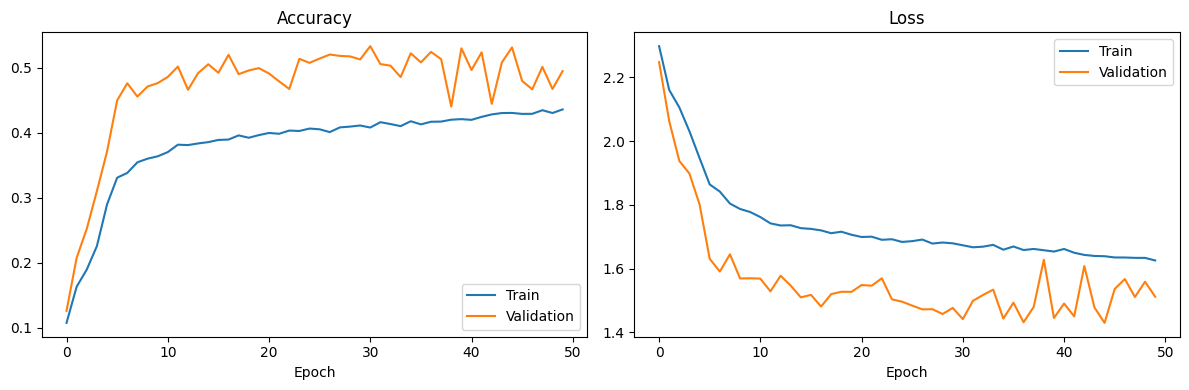

In [ ]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history.history['accuracy'],     label='Train')
ax1.plot(history.history['val_accuracy'], label='Validation')
ax1.set_title('Accuracy')
ax1.set_xlabel('Epoch')
ax1.legend()

ax2.plot(history.history['loss'],     label='Train')
ax2.plot(history.history['val_loss'], label='Validation')
ax2.set_title('Loss')
ax2.set_xlabel('Epoch')
ax2.legend()

plt.tight_layout()
plt.show()

In [ ]:
tf.keras.backend.clear_session()

model = keras.Sequential([
    keras.Input(shape=(32, 32)),
    layers.Flatten(),

    layers.Dense(1024),
    layers.BatchNormalization(),    # ← new
    layers.Activation('relu'),
    layers.Dropout(0.3),

    layers.Dense(512),
    layers.BatchNormalization(),    # ← new
    layers.Activation('relu'),
    layers.Dropout(0.3),

    layers.Dense(256),
    layers.BatchNormalization(),    # ← new
    layers.Activation('relu'),
    layers.Dropout(0.2),

    layers.Dense(128),
    layers.BatchNormalization(),    # ← new
    layers.Activation('relu'),

    layers.Dense(10, activation='softmax')
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Learning rate schedule + early stopping
callbacks = [
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,        # halve the learning rate
        patience=5,        # wait 5 epochs before reducing
        min_lr=0.00001,
        verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=10,       # stop if no improvement for 10 epochs
        restore_best_weights=True,  # keep best model
        verbose=1
    )
]

history = model.fit(
    X_train, y_train,
    epochs=100,            # early stopping will kick in
    batch_size=64,
    validation_split=0.1,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/100
591/591 ━━━━━━━━━━━━━━━━━━━━ 14s 14ms/step - accuracy: 0.4454 - loss: 1.6237 - val_accuracy: 0.5260 - val_loss: 1.4539 - learning_rate: 0.0010
Epoch 2/100
591/591 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6390 - loss: 1.1188 - val_accuracy: 0.5690 - val_loss: 1.3417 - learning_rate: 0.0010
Epoch 3/100
591/591 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6888 - loss: 0.9745 - val_accuracy: 0.6326 - val_loss: 1.1087 - learning_rate: 0.0010
Epoch 4/100
591/591 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7125 - loss: 0.9010 - val_accuracy: 0.6190 - val_loss: 1.1762 - learning_rate: 0.0010
Epoch 5/100
591/591 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7279 - loss: 0.8450 - val_accuracy: 0.6502 - val_loss: 1.0564 - learning_rate: 0.0010
Epoch 6/100
591/591 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7465 - loss: 0.7992 - val_accuracy: 0.6717 - val_loss: 1.0069 - learning_rate: 0.0010
Epoch 7/100
591/591 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7591 - loss: 

In [ ]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test accuracy: {test_acc:.4f}")
print(f"Test loss:     {test_loss:.4f}")

Test accuracy: 0.8824
Test loss:     0.4199
